# Notebook 02 — Preprocessing
**CIS6035 IHMS — Somerset Mirissa Beach Hotel**

Goals:
- Parse and set datetime index
- Check for missing dates (gaps in the series)
- Run ADF stationarity test on `occupancy_rate`
- Plot ACF/PACF to inform ARIMA orders
- Create time-based train/val/test split (no shuffling)
- Save splits to `data/splits/` for downstream notebooks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

os.makedirs('../data/splits', exist_ok=True)
os.makedirs('../docs/figures', exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Load data with proper date parsing
df = pd.read_csv('../data/hotel_data.csv')
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
df = df.sort_values('date').set_index('date')

print(f'Shape: {df.shape}')
print(f'Index: {df.index.min()} → {df.index.max()}')
df.head()

Shape: (1096, 8)
Index: 2023-01-01 00:00:00 → 2025-12-31 00:00:00


,total_rooms,booked_rooms,occupancy_rate,month,is_weekend,season,is_holiday,revenue
date,,,,,,,,
2023-01-01,15,12,0.80,1,1,very_high,0,545904
2023-01-02,15,11,0.73,1,0,very_high,0,370480
2023-01-03,15,11,0.73,1,0,very_high,0,468325
2023-01-04,15,12,0.80,1,0,very_high,0,453480
2023-01-05,15,13,0.87,1,0,very_high,1,527280


In [3]:
# Check for gaps in the daily series
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing = full_range.difference(df.index)
print(f'Expected days: {len(full_range)}')
print(f'Actual days:   {len(df)}')
print(f'Missing dates: {len(missing)}')
if len(missing) > 0:
    print(missing)
else:
    print('No gaps — clean continuous series.')

Expected days: 1096
Actual days:   1096
Missing dates: 0
No gaps — clean continuous series.


In [4]:
# ADF Stationarity Test on occupancy_rate
def adf_test(series, name='occupancy_rate'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'=== ADF Test — {name} ===')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Critical values:')
    for k, v in result[4].items():
        print(f'  {k}: {v:.4f}')
    if result[1] < 0.05:
        print('>>> STATIONARY (reject H0 at 5%)')
    else:
        print('>>> NON-STATIONARY (fail to reject H0)')
    return result

adf_result = adf_test(df['occupancy_rate'])

=== ADF Test — occupancy_rate ===
ADF Statistic : -2.6710
p-value       : 0.0792
Critical values:
  1%: -3.4365
  5%: -2.8642
  10%: -2.5682
>>> NON-STATIONARY (fail to reject H0)


In [5]:
# If non-stationary, test first difference
occ_diff = df['occupancy_rate'].diff().dropna()
adf_result_diff = adf_test(occ_diff, name='occupancy_rate (1st diff)')

=== ADF Test — occupancy_rate (1st diff) ===
ADF Statistic : -7.8183
p-value       : 0.0000
Critical values:
  1%: -3.4365
  5%: -2.8642
  10%: -2.5682
>>> STATIONARY (reject H0 at 5%)


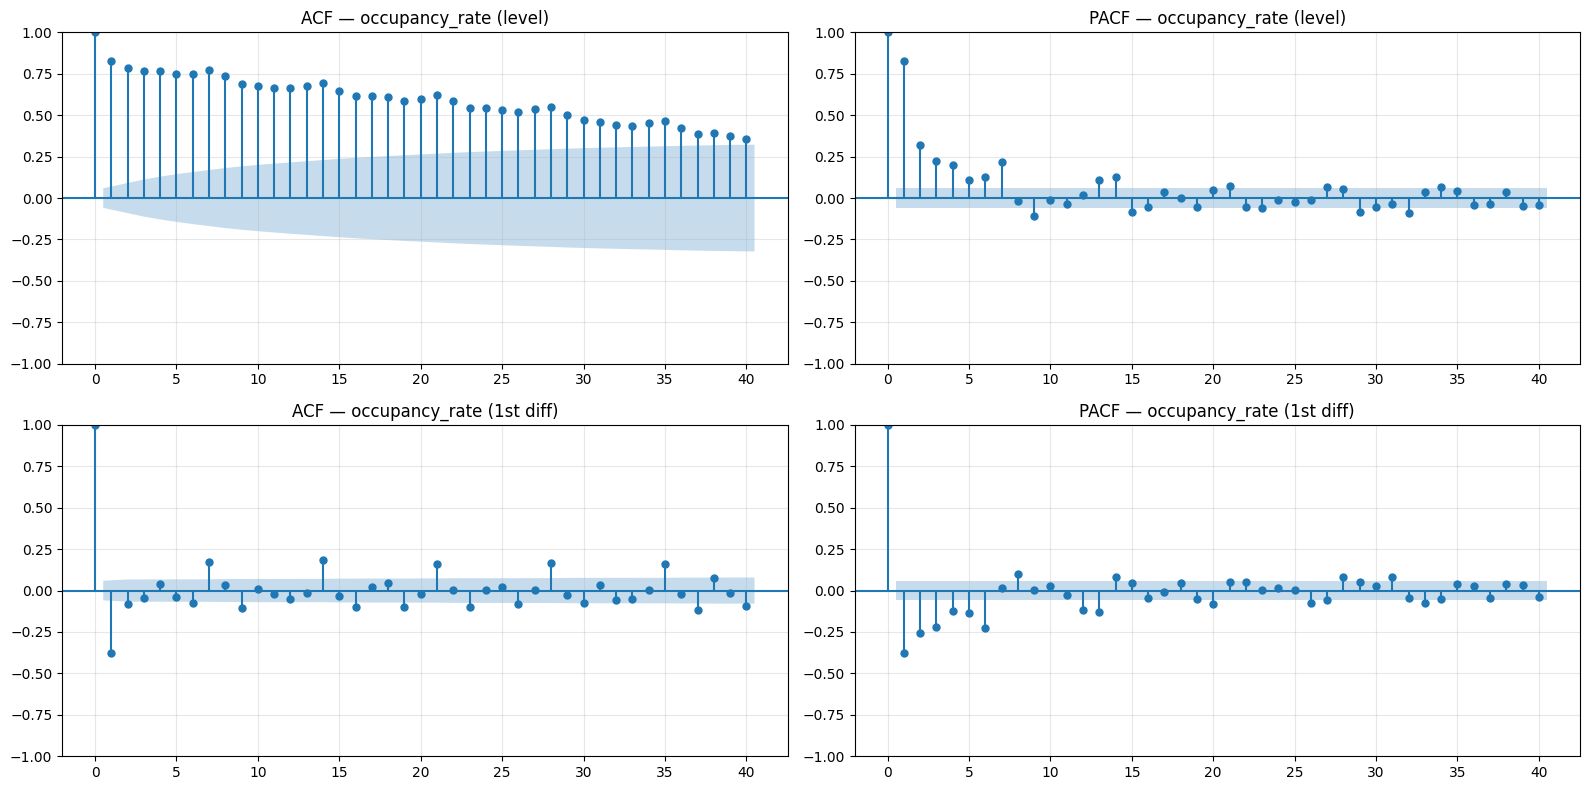

In [6]:
# ACF / PACF plots
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(df['occupancy_rate'], lags=40, ax=axes[0, 0], title='ACF — occupancy_rate (level)')
plot_pacf(df['occupancy_rate'], lags=40, ax=axes[0, 1], title='PACF — occupancy_rate (level)', method='ols')
plot_acf(occ_diff, lags=40, ax=axes[1, 0], title='ACF — occupancy_rate (1st diff)')
plot_pacf(occ_diff, lags=40, ax=axes[1, 1], title='PACF — occupancy_rate (1st diff)', method='ols')

plt.tight_layout()
plt.savefig('../docs/figures/02_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Train / Validation / Test split (time-based — NO shuffling)
# Train: 2023 (365 days)
# Val:   2024 (366 days — leap year)
# Test:  2025 (365 days)

train = df['2023-01-01':'2023-12-31']
val   = df['2024-01-01':'2024-12-31']
test  = df['2025-01-01':'2025-12-31']

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)')
print(f'Val:   {val.index.min().date()} → {val.index.max().date()}    ({len(val)} days)')
print(f'Test:  {test.index.min().date()} → {test.index.max().date()}  ({len(test)} days)')

# Verify no overlap
assert len(set(train.index) & set(val.index)) == 0, 'OVERLAP: train/val'
assert len(set(val.index)   & set(test.index)) == 0, 'OVERLAP: val/test'
print('\nSplit integrity verified — no overlaps.')

Train: 2023-01-01 → 2023-12-31  (365 days)
Val:   2024-01-01 → 2024-12-31    (366 days)
Test:  2025-01-01 → 2025-12-31  (365 days)

Split integrity verified — no overlaps.


Splits saved to data/splits/


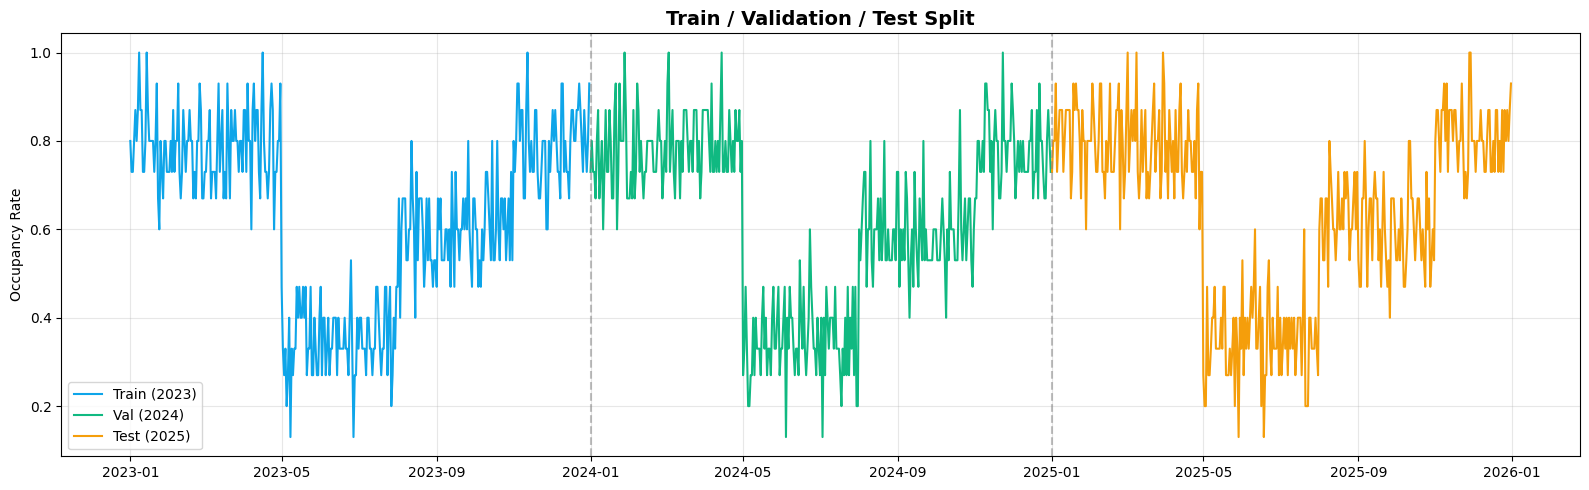

In [7]:
# Save splits
train.to_csv('../data/splits/train.csv')
val.to_csv('../data/splits/val.csv')
test.to_csv('../data/splits/test.csv')
print('Splits saved to data/splits/')

# Visualise the split
plt.figure(figsize=(16, 5))
plt.plot(train.index, train['occupancy_rate'], label='Train (2023)', color='#0ea5e9')
plt.plot(val.index,   val['occupancy_rate'],   label='Val (2024)',   color='#10b981')
plt.plot(test.index,  test['occupancy_rate'],  label='Test (2025)',  color='#f59e0b')
plt.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle='--', alpha=0.5)
plt.axvline(pd.Timestamp('2025-01-01'), color='gray', linestyle='--', alpha=0.5)
plt.title('Train / Validation / Test Split', fontsize=14, fontweight='bold')
plt.ylabel('Occupancy Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/figures/02_splits.png', dpi=150, bbox_inches='tight')
plt.show()